# Question 1: Data Preparation and Processing with Pandas

## Step 1: Load and Inspect Data

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [64]:
# Load all three CSV files
orders = pd.read_csv('orders.csv')
products = pd.read_csv('products.csv')
customers = pd.read_csv('customers.csv')

### orders

In [65]:
orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Sales,Quantity,Discount,Profit
0,CA-2019-103800,2019-01-03,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512
1,CA-2019-112326,2019-01-04,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717
2,CA-2019-112326,2019-01-04,PO-19195,OFF-ST-10002743,272.736,3,0.2,-64.7748
3,CA-2019-112326,2019-01-04,PO-19195,OFF-BI-10004094,3.540,2,0.8,-5.4870
4,CA-2019-141817,2019-01-05,MB-18085,OFF-AR-10003478,19.536,3,0.2,4.8840


In [66]:
orders.shape

(9994, 8)

### products

In [67]:
products.head()

,ProductID,Category,SubCategory,ProductName
0,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form..."
1,OFF-LA-10003223,Office Supplies,Labels,Avery 508
2,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving
3,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs
4,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...


In [24]:
products.shape

(1862, 4)

### customers

In [68]:
customers.head()

,CustomerID,CustomerName,Segment,Region,State,City
0,DP-13000,Darren Powers,Consumer,Central,Texas,Houston
1,PO-19195,Phillina Ober,Home Office,Central,Illinois,Naperville
2,MB-18085,Mick Brown,Consumer,East,Pennsylvania,Philadelphia
3,ME-17320,Maria Etezadi,Home Office,South,Kentucky,Henderson
4,JO-15145,Jack O'Briant,Corporate,South,Georgia,Athens


In [31]:
customers.shape

(793, 6)

## Step 2: Merging DataFrames

In [90]:
# Step 1: Merge orders with products on ProductID
merged1 = pd.merge(orders, products, on='ProductID', how='inner')

# Step 2: Merge result with customers on CustomerID
master_df = pd.merge(merged1, customers, on='CustomerID', how='inner')

print(f"master_df shape:{ master_df.shape}")
print(f"Columns:{master_df.columns.tolist()}")
master_df.head()

master_df shape:(9994, 16)
Columns:['OrderID', 'OrderDate', 'CustomerID', 'ProductID', 'Sales', 'Quantity', 'Discount', 'Profit', 'Category', 'SubCategory', 'ProductName', 'CustomerName', 'Segment', 'Region', 'State', 'City']


,OrderID,OrderDate,CustomerID,ProductID,Sales,Quantity,Discount,Profit,Category,SubCategory,ProductName,CustomerName,Segment,Region,State,City
0,CA-2019-103800,2019-01-03,DP-13000,OFF-PA-10000174,16.448,2,0.2,5.5512,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Darren Powers,Consumer,Central,Texas,Houston
1,CA-2019-112326,2019-01-04,PO-19195,OFF-LA-10003223,11.784,3,0.2,4.2717,Office Supplies,Labels,Avery 508,Phillina Ober,Home Office,Central,Illinois,Naperville
2,CA-2019-112326,2019-01-04,PO-19195,OFF-ST-10002743,272.736,3,0.2,-64.7748,Office Supplies,Storage,SAFCO Boltless Steel Shelving,Phillina Ober,Home Office,Central,Illinois,Naperville
3,CA-2019-112326,2019-01-04,PO-19195,OFF-BI-10004094,3.540,2,0.8,-5.4870,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,Phillina Ober,Home Office,Central,Illinois,Naperville
4,CA-2019-141817,2019-01-05,MB-18085,OFF-AR-10003478,19.536,3,0.2,4.8840,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Mick Brown,Consumer,East,Pennsylvania,Philadelphia


## Step 3: Feature Engineering

In [91]:
# UnitPrice = Sales / Quantity
master_df['UnitPrice'] = master_df['Sales'] / master_df['Quantity']

# Margin = Profit / Sales
master_df['Margin'] = master_df['Profit'] / master_df['Sales']

master_df[['Sales', 'Quantity', 'Profit', 'UnitPrice', 'Margin']].head()

,Sales,Quantity,Profit,UnitPrice,Margin
0,16.448,2,5.5512,8.224,0.3375
1,11.784,3,4.2717,3.928,0.3625
2,272.736,3,-64.7748,90.912,-0.2375
3,3.540,2,-5.4870,1.770,-1.5500
4,19.536,3,4.8840,6.512,0.2500


## Step 4: Time Series Analysis

In [92]:
master_df['OrderDate'] = pd.to_datetime(master_df['OrderDate'])
master_df = master_df.set_index('OrderDate').sort_index()

monthly = master_df[['Sales', 'Profit']].resample('ME').sum()
print(f"monthly:\n{monthly}")

monthly:
                  Sales      Profit
OrderDate                          
2019-01-31   14236.8950   2450.1907
2019-02-28    4519.8920    862.3084
2019-03-31   55691.0090    498.7299
2019-04-30   28295.3450   3488.8352
2019-05-31   23648.2870   2738.7096
2019-06-30   34595.1276   4976.5244
2019-07-31   33946.3930   -841.4826
2019-08-31   27909.4685   5318.1050
2019-09-30   81777.3508   8328.0994
2019-10-31   31453.3930   3448.2573
2019-11-30   78628.7167   9292.1269
2019-12-31   69545.6205   8983.5699
2020-01-31   18174.0756  -3281.0070
2020-02-29   13593.5854   2826.5690
2020-03-31   37084.0776   9719.3796
2020-04-30   34646.1485   4253.7196
2020-05-31   30514.9445   4902.1242
2020-06-30   23963.0940   3035.0786
2020-07-31   29777.0210   3116.1375
2020-08-31   38254.2002   6280.2620
2020-09-30   63386.7680   7626.9201
2020-10-31   33352.6155   3569.7223
2020-11-30   79997.0515  12505.8409
2020-12-31   67788.9272   7063.8569
2021-01-31   18704.4610   2888.0395
2021-02-28   22816.

In [103]:
best_month = monthly['Sales'].idxmax()
print(f"Month with highest Sales: {best_month.strftime('%Y-%m')} | Sales = {monthly.loc[best_month, 'Sales']:,.2f}")

Month with highest Sales: 2022-11 | Sales = 118,447.82


## Which month had the highest sales?
>November 2022 (2022-11) had the highest total sales with $118,447.82

## Step 5: Customer Segmentation with Pivot Table

In [120]:
profit_by_segment = pd.pivot_table(
    master_df.reset_index(),
    index='Segment',
    columns='Category',
    values='Profit',
    aggfunc='sum'
)

technology_profit = profit_by_segment["Technology"]

top_segment = technology_profit.idxmax()
top_profit = technology_profit.loc[top_segment]

print(profit_by_segment.round(2))

print(
    f"\nTop Technology Segment: "
    f"{top_segment} | "
    f"Profit = ${top_profit:,.2f}"
)

Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer       6991.08         56330.32    70797.81
Corporate      7584.82         40227.32    44167.00
Home Office    3875.38         25933.16    30490.14

Top Technology Segment: Consumer | Profit = $70,797.81


## Which segment generated the most profit in Technology?
>Consumer segment generated the highest profit in Technology: $70,797.81

# Question 2: Data Visualization with Matplotlib and Seaborn

## Step 1: Sales vs Profit Trend

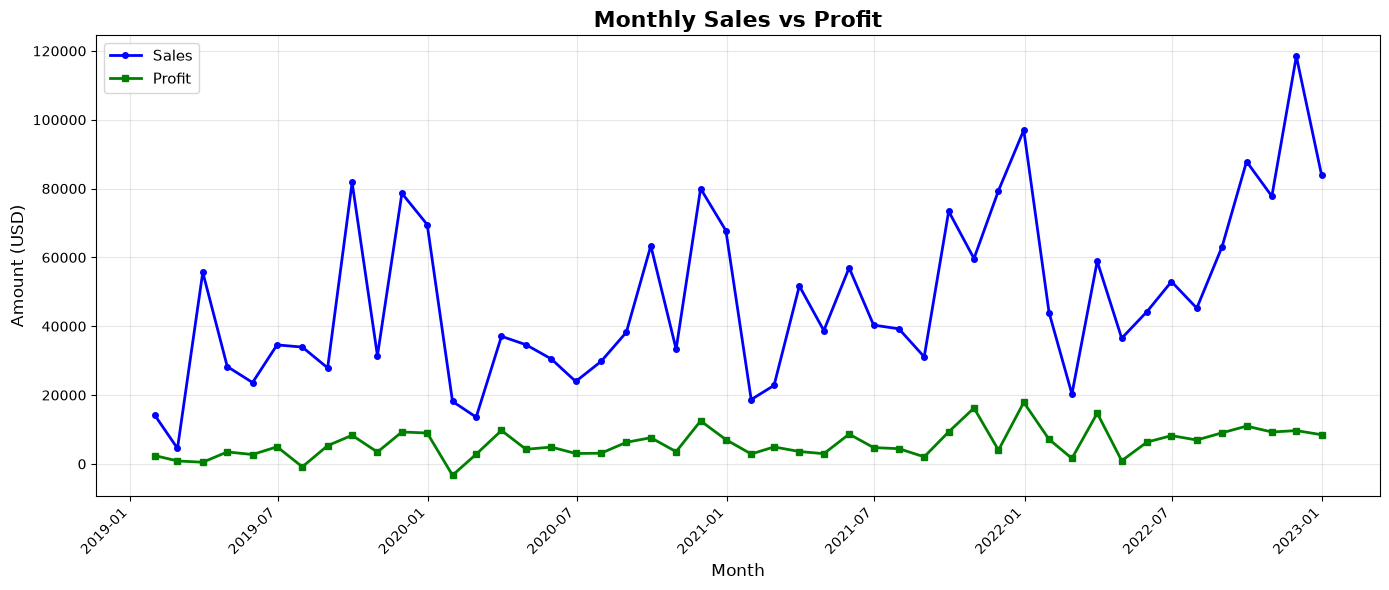

In [121]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly.index, monthly['Sales'], color='blue', linewidth=2, marker='o', markersize=4, label='Sales')
ax.plot(monthly.index, monthly['Profit'], color='green', linewidth=2, marker='s', markersize=4, label='Profit')
ax.set_title('Monthly Sales vs Profit', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Amount (USD)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart1_monthly_sales_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis: 
>Sales and profit do not always move together. For example, in November 2022, sales peaked dramatically but profit remained relatively modest — indicating high-volume, low-margin transactions. Some months show high sales but below-average profit (e.g., heavy discounting periods). This decoupling is a key business insight.

## Step 2: Checking the performance of categories

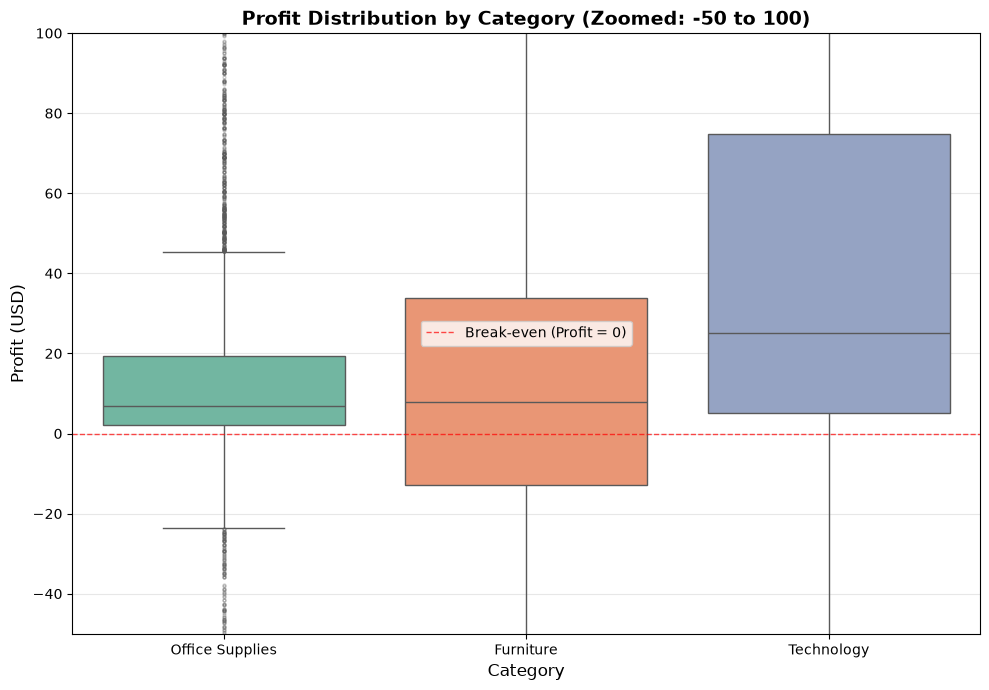

Negative profit transactions per category:
Category
Furniture          714
Office Supplies    886
Technology         271
dtype: int64


In [124]:
fig, ax = plt.subplots(figsize=(10, 7))
df_reset = master_df.reset_index()
sns.boxplot(data=df_reset, x='Category', y='Profit', hue='Category',
            palette='Set2', legend=False, ax=ax, flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_ylim(-50, 100)
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Break-even (Profit = 0)')
ax.set_title('Profit Distribution by Category (Zoomed: -50 to 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Profit (USD)', fontsize=12)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('chart2_profit_boxplot_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Count negative profit transactions
Negative_profit = df_reset[df_reset['Profit'] < 0].groupby('Category').size()
print(f"Negative profit transactions per category:\n{Negative_profit}")


## Analysis:
>Office Supplie has the most negative-profit transactions (886), followed by Furniture (714) and Technology (271). However, Furniture shows the widest spread of losses below zero, suggesting structural margin issues often driven by heavy discounting on larger items.

## Step 3: The impact of discounts

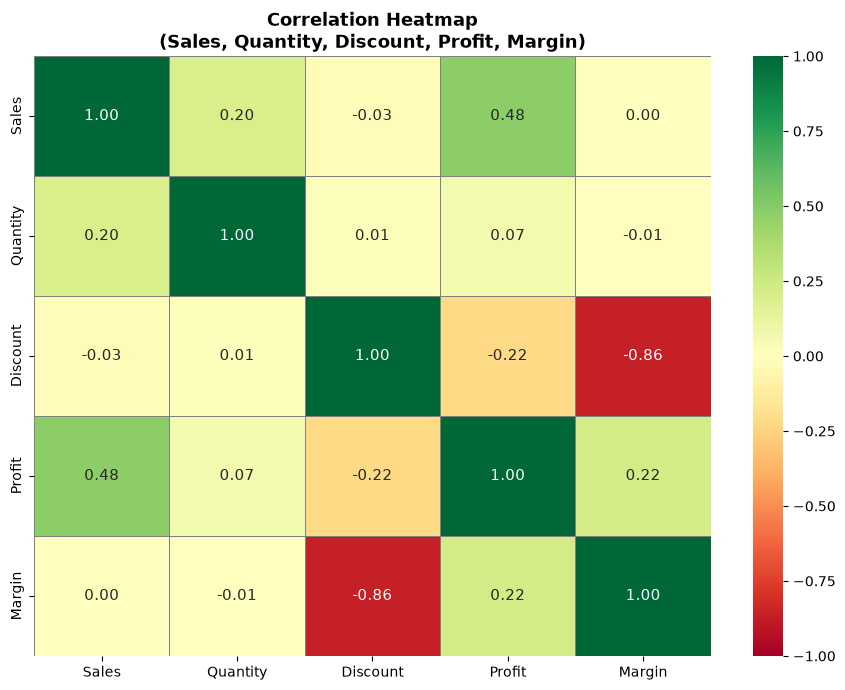


Correlation Analysis
Discount vs Profit correlation: -0.219
Discount vs Margin correlation: -0.864


In [129]:
cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Margin']
corr_matrix = master_df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='gray',
    ax=ax, annot_kws={'size': 11}
)
ax.set_title('Correlation Heatmap\n(Sales, Quantity, Discount, Profit, Margin)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation Analysis")
print("Discount vs Profit correlation:", round(corr_matrix.loc['Discount','Profit'], 3))
print("Discount vs Margin correlation:", round(corr_matrix.loc['Discount','Margin'], 3))

## Analysis:
>The correlation between Discount and Profit is negative (≈ -0.22), meaning higher discounts are associated with lower profits. Even stronger, Discount vs Margin is -0.86 — a very strong negative relationship.  

>Conclusion: The store's discounting strategy is harmful to profitability. Giving discounts does not translate to enough extra volume to compensate for margin loss. This signals a need to redesign the discount strategy — targeting only specific high-inventory or seasonal items rather than broad discounting.